In [133]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

In [134]:
a_curved = [2,3]#"1.2-0.3*s"]#"1-s**2"]
b_curved = [1,4]#"4-s**4"]
h= b_curved[0] #considering normalization B/Brho=1/rho=h   

Then work at the level of the scalar potential because being a scalar it is invariant under change of frame (only the coordinates change). Because of this we can move to the straight frame and perform a harmonic analysis, checking how the a,b coefficients look in that frame.

phi curved frame:  -3*x**2/2 - 2*x + y**6*(-4608.0*x - 4608.0)/(720*(512.0*x**6 + 3072.0*x**5 + 7680.0*x**4 + 10240.0*x**3 + 7680.0*x**2 + 3072.0*x + 512.0)) - y**5*(4.0*x + 4.0)/(120*(1.0*x**4 + 4.0*x**3 + 6.0*x**2 + 4.0*x + 1.0)) - y**4*(-8.0*x - 8.0)/(24*(8.0*x**4 + 32.0*x**3 + 48.0*x**2 + 32.0*x + 8.0)) + y**3*(4.0*x + 4.0)/(6*(1.0*x + 1)**2) + y**2*(6.0*x + 5.0)/(2*(1.0*x + 1)) - y*(4*x + 1)

phi straight frame:  -6.4*y**6*sqrt(s**2 + (x + 1.0)**2)/(3072.0*sqrt(s**2 + (x + 1.0)**2) + 512.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**6 + 3072.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**5 + 7680.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 10240.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 7680.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 2560.0) - 0.0333333333333333*y**5*sqrt(s**2 + (x + 1.0)**2)/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0) + 0.333333333333333*y**4*sqrt(s**2 + (x + 1.0)**2

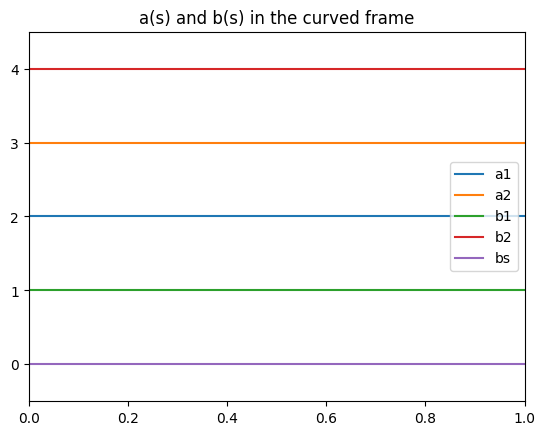

In [135]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=7)#, nphi=nphi)
phi_curved = expansion_curved.get_phi()
expansion_curved.plot_components()
plt.xlim((0,1))
plt.ylim((-0.5,4.5))
plt.title("a(s) and b(s) in the curved frame")
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

Remembering that $ \phi_0(x, s) = -a_0(s) - \sum_{n=1}^\infty a_n(s) \frac{x^n}{n!} \\
    \phi_1(x, s) = -\sum_{n=1}^\infty b_n(s) \frac{x^{n-1}}{(n-1)!}  $

we can take the coefficient of y in phi_straight, which is $\phi_1$, expand it in a Taylor series in x around 0 up to some order, e.g. 4, (strip the big-O), and store the resulting polynomial’s coefficients in a dictionary keyed by powers of x. This corresponds to

 $\frac{b_n}{(n-1)!}$

 and the same for $a_n$ considering that \\
phi0 = phi_straight.as_coefficients_dict(y)[1]   # phi_0(x, s)$
.

phi1 = -(4*sqrt(s**2 + (x + 1.0)**2) - 3.0)


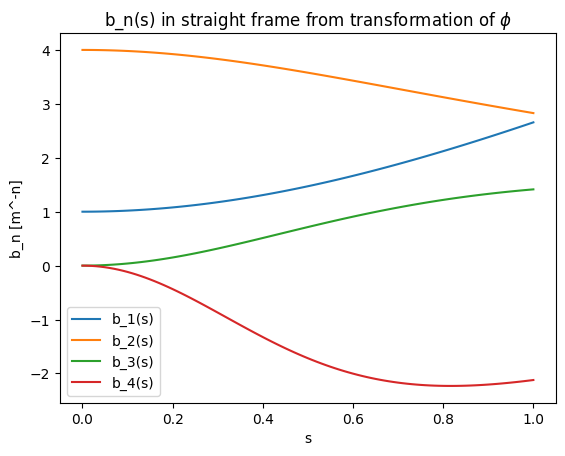

phi0 = -2*sqrt(s**2 + (x + 1.0)**2) - 3*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/2 + 2.0


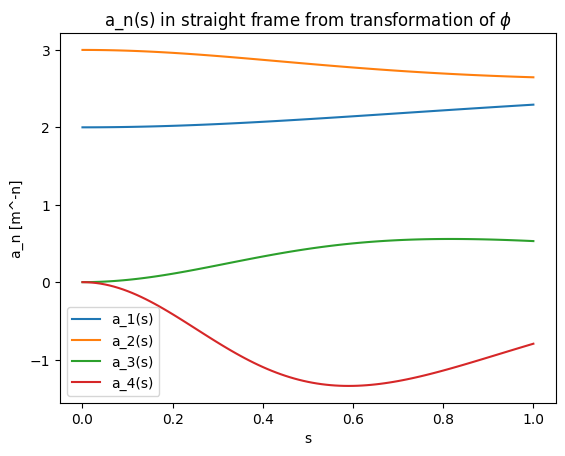

In [154]:
maxordx = 3
ns = 101
ss = np.linspace(1e-4, 1, ns)  # avoid the removable singularity at s=0 in the transformed phi expressions

# ===========================
# b_n(s) from phi1 (b_1 = constant term) — as before
# ===========================
phi1 = phi_straight.as_coefficients_dict(y)[y]
print("phi1 =", phi1)

b_vals = np.zeros((maxordx + 1, ss.size))   # rows: n=0→b_1, n=1→b_2, ...

if phi1 != 0:
    phi1_series = phi1.series(x, 0, maxordx + 1).removeO()
    dct_b = phi1_series.as_coefficients_dict(x)
    items_b = list(dct_b.items())

    # first: compute and store all b_n
    for xx, vv in items_b:
        n = sp.degree(xx, x)
        if n is None or n > maxordx:
            continue

        if n == 0:
            b_n = -vv                  # b_1(s): constant term
            idx = 0                    # row 0 → b_1
        else:
            b_n = -vv * sp.factorial(n)  # b_{n+1}(s)
            idx = n                    # row n → b_{n+1}

        b_fun = sp.lambdify(s, b_n, 'numpy')
        with np.errstate(divide='ignore', invalid='ignore'):
            vals = np.asarray(b_fun(ss), dtype=float)
        b_vals[idx, :] = np.where(np.isfinite(vals), vals, np.nan)

# second: plot in desired order: b_1, b_2, ...
for idx in range(maxordx + 1):
    label = f"b_{idx+1}(s)"            # row 0→b_1, row 1→b_2, etc.
    plt.plot(ss, b_vals[idx, :], label=label)

plt.legend()
plt.title("b_n(s) in straight frame from transformation of $\\phi$")
plt.ylabel("b_n [m^-n]")
plt.xlabel("s")
plt.show()

# ===========================
# a_n(s) from phi0 (a_1 = coefficient of x^1)
# ===========================
phi0 = phi_straight.as_coefficients_dict(y)[1]
print("phi0 =", phi0)

a_vals = np.zeros((maxordx + 2, ss.size))   # rows: 0→a_1 (from x^1), 1→a_2 (from x^2), ...

if phi0 != 0:
    phi0_series = phi0.series(x, 0, maxordx + 2).removeO()
    dct_a = phi0_series.as_coefficients_dict(x)
    items_a = list(dct_a.items())

    for xx, vv in items_a:
        deg = sp.degree(xx, x)
        if deg is None:
            continue

        # your convention: a_1 comes from degree 1, a_2 from degree 2, etc.
        if deg >= 1 and deg <= maxordx + 2:
            n = deg          # coefficient of x^n
            idx = n - 1      # store in row (n-1): x^1→row 0 (a_1), x^2→row 1 (a_2)

            a_n = -vv * sp.factorial(n)  # or your chosen normalization

            a_fun = sp.lambdify(s, a_n, 'numpy')
            with np.errstate(divide='ignore', invalid='ignore'):
                vals = np.asarray(a_fun(ss), dtype=float)
            a_vals[idx, :] = np.where(np.isfinite(vals), vals, np.nan)

            label = f"a_{idx+1}(s)"      # row 0→a_1, row 1→a_2, etc.
            plt.plot(ss, a_vals[idx, :], label=label)

    # (optional) handle constant term separately if you need it, but not as a_n
else:
    for idx in range(maxordx + 2):
        label = f"a_{idx+1}(s)"
        plt.plot(ss, a_vals[idx, :], label=label)

plt.legend()
plt.title("a_n(s) in straight frame from transformation of $\\phi$")
plt.xlabel("s")
plt.ylabel('a_n [m^-n]')
plt.show()

In [155]:
# evaluate fields on cartesian grid 
xstraightarray = np.linspace(-1, 1, 100)
ystraightarray = np.linspace(-1, 1, 100)
sstraightarray = ss  # same s array used before

Xstraight, Ystraight, Sstraight = np.meshgrid(xstraightarray, ystraightarray, sstraightarray, indexing='ij')
Bxstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bxstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bystraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bystraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
Bsstraight_ana_array = np.asarray(sp.lambdify((x, y, s), Bsstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight))
shape = Xstraight.shape  # reshape to (Nx, Ny, Ns)
Bxstraight_ana_array = np.broadcast_to(Bxstraight_ana_array, shape).copy()
Bystraight_ana_array = np.broadcast_to(Bystraight_ana_array, shape).copy()
Bsstraight_ana_array = np.broadcast_to(Bsstraight_ana_array, shape).copy()
#make a fieldmap object from the field arrays
print(Bxstraight_ana_array.shape)
datastraightfm = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_ana_array.flatten(), Bystraight_ana_array.flatten(), Bsstraight_ana_array.flatten()))
#fm_straight = bpmeth.fieldmaps.Fieldmap(datastraightfm)
#before making the HA, sample the field on a cylindrical grid
ntheta=256
nr=100

def interp_cartesian_to_cylindrical(cart_fieldmap, x_1d, y_1d, s_1d, rmin=0.01, rmax=0.4, nr=nr,ntheta=ntheta, ns=ns):
    """
    Convert Cartesian fieldmap to cylindrical 
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    Returns
    -------
    fields: list
        list containing Bx, By, Bs
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = s_1d
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    return rr, theta_1d, fields
rr, theta_1d, cylfieldatadict= interp_cartesian_to_cylindrical(datastraightfm, x_1d=xstraightarray, y_1d=ystraightarray, s_1d=sstraightarray, rmin=0.01, rmax=0.4, nr=nr, ntheta=ntheta, ns=ns)
rarr, tarr, sarr = np.meshgrid(rr, theta_1d, sstraightarray, indexing='ij')
cylfieldmapdatastack= np.column_stack([rarr.ravel(), tarr.ravel(), sarr.ravel(), cylfieldatadict['Bx'].ravel(), cylfieldatadict['By'].ravel(), cylfieldatadict['Bs'].ravel()])

(100, 100, 101)


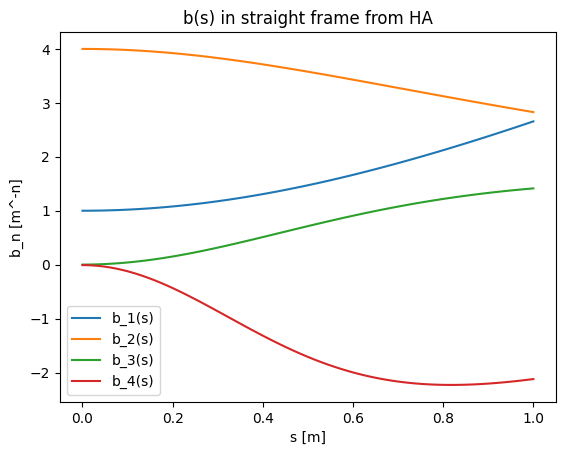

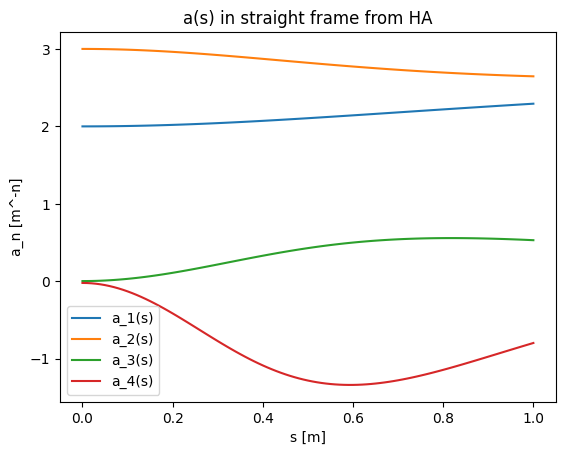

In [156]:
fm_straight_cyl= bpmeth.fieldmaps.Fieldmap(cylfieldmapdatastack)
orderHA=4
svals, astraightofs, bstraightofs, erroras, errorbs = fm_straight_cyl.s_harmonics(rr=rr, ntheta=ntheta, ns=ns, order=orderHA)
for i, b in enumerate(bstraightofs.T):
    plt.plot(svals, b, label=f"b_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('b_n [m^-n]')
plt.title('b(s) in straight frame from HA')
plt.legend()
plt.show()
for i, a in enumerate(astraightofs.T):
    plt.plot(svals, a, label=f"a_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('a_n [m^-n]')
plt.title('a(s) in straight frame from HA')
plt.legend()
plt.show()

As expected an s dependence appeared. To asses the importance of not neglecting it we can see what are the predictions of a naive tracking that would disregard the effect of curvature compared with a more advanced one. 

4
4 101


<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\p'
/tmp/fmarcoli/ipykernel_10856/2972065497.py:6: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals, d, label=f"$\Delta b_{i+1}(s)$")
/tmp/fmarcoli/ipykernel_10856/2972065497.py:15: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(svals, d, label=f"$\Delta$a_{i+1}(s)")
/tmp/fmarcoli/ipykernel_10856/2972065497.py:24: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(sva

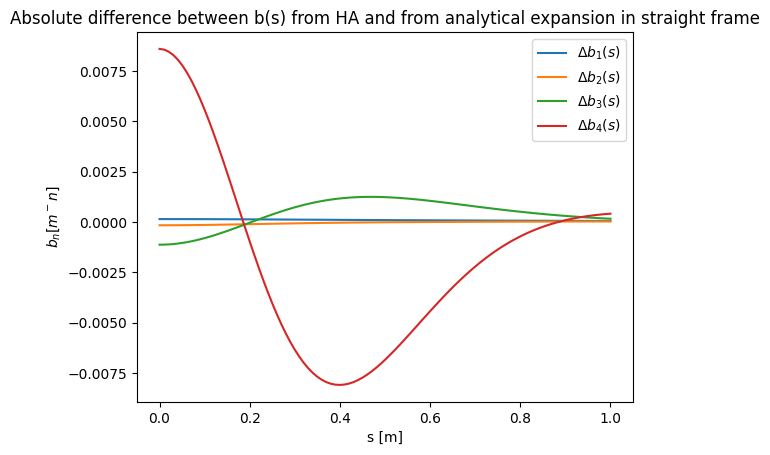

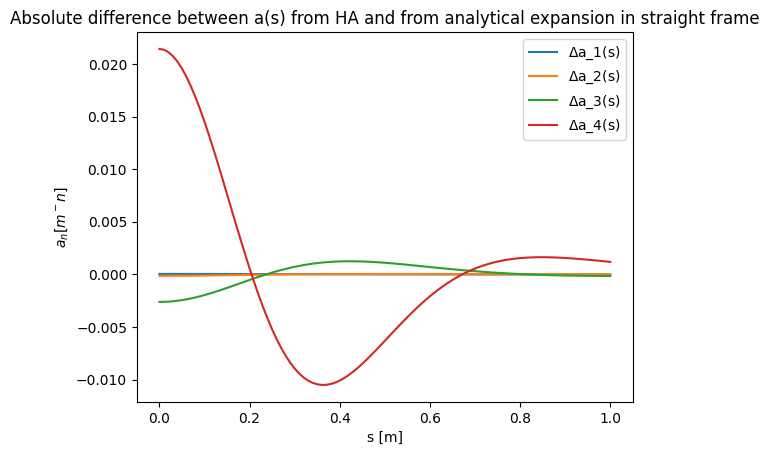

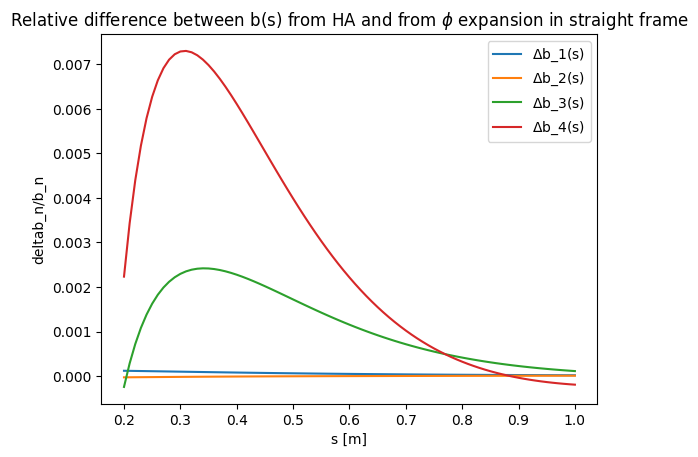

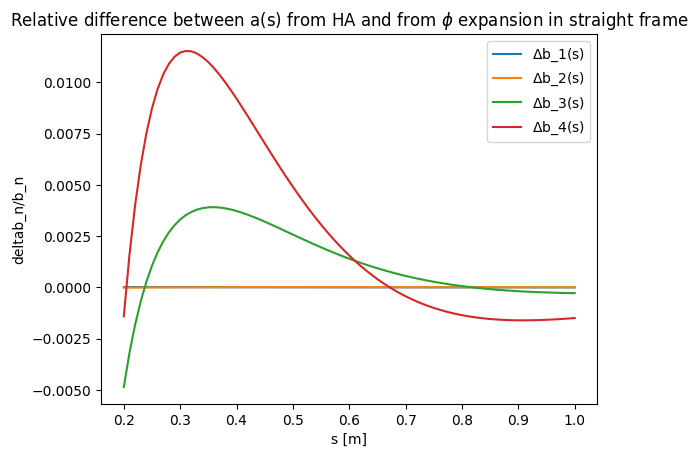

In [157]:
commonsize=min(bstraightofs[0].size,b_vals.T[0].size)
print(commonsize)
print(bstraightofs[0].size, bstraightofs.T[0].size)
deltab=b_vals[:commonsize,:]-bstraightofs.T[:commonsize,:] 
for i, d in enumerate(deltab[:commonsize]):
    plt.plot(svals, d, label=f"$\Delta b_{i+1}(s)$")
plt.xlabel('s [m]')
plt.ylabel('$b_n [m^-n]$')
plt.title('Absolute difference between b(s) from HA and from analytical expansion in straight frame')
plt.legend()
plt.show()

deltaa=a_vals[:commonsize,:]-astraightofs.T[:commonsize,:] 
for i, d in enumerate(deltaa[:commonsize]):
    plt.plot(svals, d, label=f"$\Delta$a_{i+1}(s)")
plt.xlabel('s [m]')
plt.ylabel('$a_n [m^-n]$')
plt.legend()
plt.title('Absolute difference between a(s) from HA and from analytical expansion in straight frame')
plt.show()

reldeltab=deltab/b_vals[:commonsize]
for i, d in enumerate(reldeltab[:commonsize]):
    plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
    
plt.xlabel('s [m]')
plt.ylabel('deltab_n/b_n')
plt.title('Relative difference between b(s) from HA and from $\phi$ expansion in straight frame')
plt.legend()
plt.show()

reldeltaa=deltaa/a_vals[:commonsize]
for i, d in enumerate(reldeltaa[:commonsize]):
    plt.plot(svals[20:], d[20:], label=f"$\Delta$b_{i+1}(s)")
    
plt.xlabel('s [m]')
plt.ylabel('deltab_n/b_n')
plt.title('Relative difference between a(s) from HA and from $\phi$ expansion in straight frame')
plt.legend()
plt.show()

degree = 20
import sympy as sp
from sympy import lambdify
b_nfit_phi = []
print(b_vals.shape, a_vals.shape)
for j in range(b_vals.shape[0]):
    coeffs = np.polyfit(ss, b_vals[j,:], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    b_nfit_phi.append(str(poly_expr))

a_nfit_phi=[]

for j in range(a_vals.shape[0]):
    coeffs = np.polyfit(ss, a_vals[j,:], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    a_nfit_phi.append(str(poly_expr))


s = sp.symbols('s')
b1ofslambdified = lambdify(s, b_nfit_phi[0], modules='numpy')
plt.plot(ss, b1ofslambdified(ss), label='recovered b1')
plt.legend()
plt.show()

a1ofslambdified = lambdify(s, a_nfit_phi[0], modules='numpy')
plt.plot(ss, a1ofslambdified(ss), label='recovered a1')
plt.legend()
plt.show()

(4, 101) (5, 101)


/tmp/fmarcoli/ipykernel_10856/3702689960.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, b_vals[j,:], deg=degree)
/tmp/fmarcoli/ipykernel_10856/3702689960.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, b_vals[j,:], deg=degree)
/tmp/fmarcoli/ipykernel_10856/3702689960.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, b_vals[j,:], deg=degree)
/tmp/fmarcoli/ipykernel_10856/3702689960.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, b_vals[j,:], deg=degree)
/tmp/fmarcoli/ipykernel_10856/3702689960.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, a_vals[j,:], deg=degree)
/tmp/fmarcoli/ipykernel_10856/3702689960.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, a_vals[j,:], deg=degree)
/tmp/fmarcoli/ipykernel_10856/3702689960.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, a_vals[

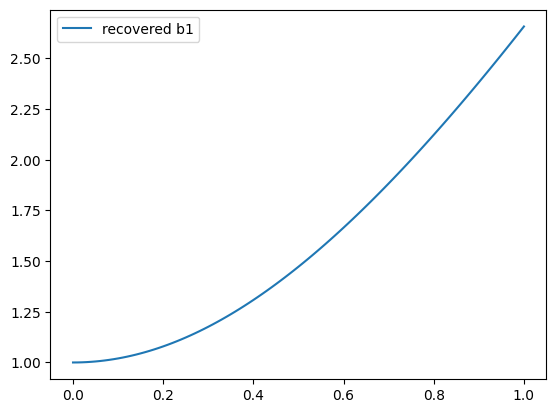

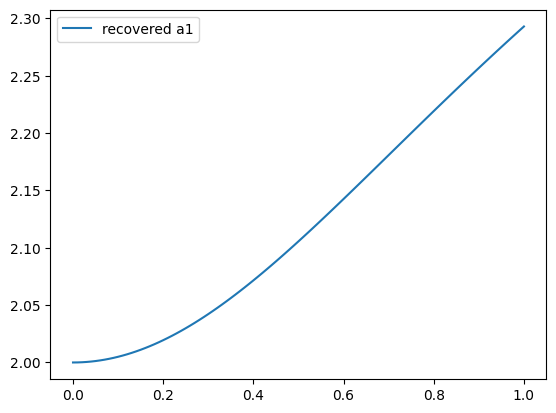

In [158]:
degree = 20
import sympy as sp
from sympy import lambdify
b_nfit_phi = []
print(b_vals.shape, a_vals.shape)
for j in range(b_vals.shape[0]):
    coeffs = np.polyfit(ss, b_vals[j,:], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    b_nfit_phi.append(str(poly_expr))

a_nfit_phi=[]

for j in range(a_vals.shape[0]):
    coeffs = np.polyfit(ss, a_vals[j,:], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    a_nfit_phi.append(str(poly_expr))


s = sp.symbols('s')
b1ofslambdified = lambdify(s, b_nfit_phi[0], modules='numpy')
plt.plot(ss, b1ofslambdified(ss), label='recovered b1')
plt.legend()
plt.show()

a1ofslambdified = lambdify(s, a_nfit_phi[0], modules='numpy')
plt.plot(ss, a1ofslambdified(ss), label='recovered a1')
plt.legend()
plt.show()

[[[-24.62702898 -24.57766516 -24.43495234 ...  -0.70156894  -0.69908272
    -0.6951517 ]
  [-23.27560563 -23.22963832 -23.09671415 ...  -0.65979551  -0.6574798
    -0.6538312 ]
  [-21.98782793 -21.94507147 -21.82140225 ...  -0.62050552  -0.61831976
    -0.61490744]
  ...
  [ -7.24210698  -7.20944446  -7.11562121 ...  -0.8069353   -0.80209305
    -0.79548924]
  [ -7.91234318  -7.87701883  -7.77556378 ...  -0.89046613  -0.88393197
    -0.87553847]
  [ -8.62703095  -8.58888014  -8.47932177 ...  -0.97900016  -0.9706394
    -0.96031717]]

 [[-23.67509983 -23.62832786 -23.49309991 ...  -0.71706523  -0.7135651
    -0.70872983]
  [-22.38387745 -22.34031929 -22.21435384 ...  -0.67605715  -0.6727314
    -0.66817535]
  [-21.15312915 -21.11260933 -20.99540187 ...  -0.63736906  -0.63417968
    -0.62985956]
  ...
  [ -6.59637521  -6.56562677  -6.47731161 ...  -0.64790636  -0.64358712
    -0.6376015 ]
  [ -7.22176978  -7.18851394  -7.0930105  ...  -0.72541937  -0.7194961
    -0.7118143 ]
  [ -7.88895

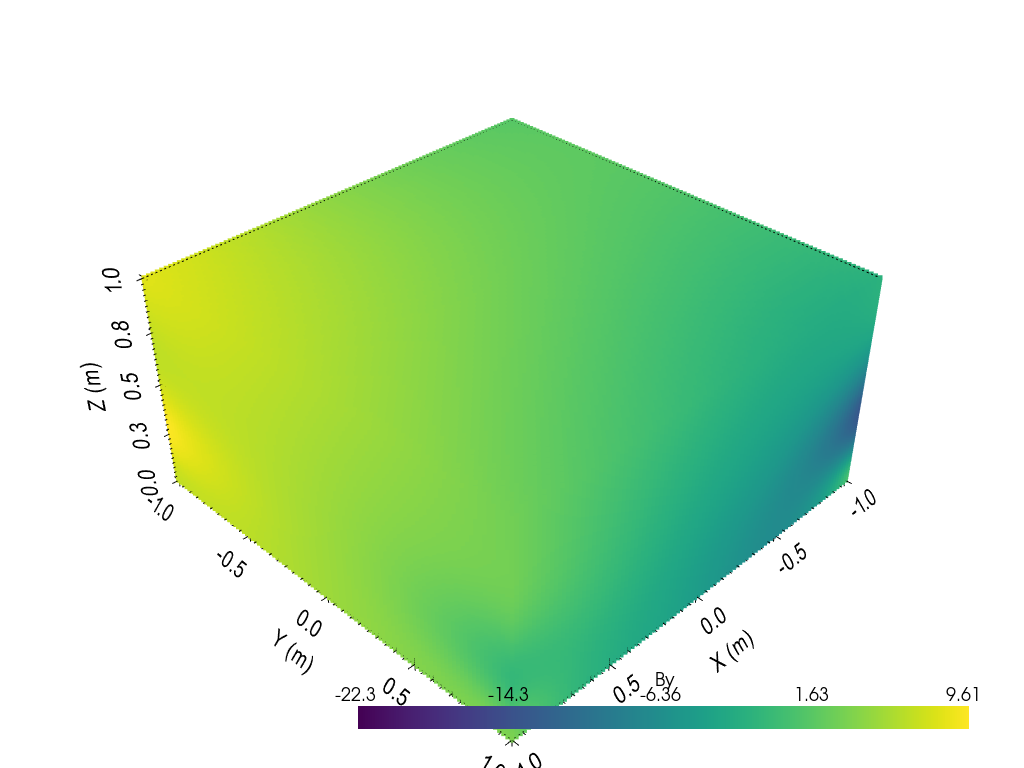

In [ ]:
# fm_straight = bpmeth.fieldmaps.Fieldmap(datastraightfm)
# fm_straight.plot()
reconstruction_from_phi=bpmeth.FieldExpansion(a=a_nfit_phi, b=b_nfit_phi) 
#make a fieldmap of this reconstruction
Bx_rec_phi, By_rec_phi, Bs_rec_phi = reconstruction_from_phi.get_Bfield(lambdify=False)
Bxstraight_phi_array = np.asarray(sp.lambdify((x, y, s), Bx_rec_phi, 'numpy')(Xstraight, Ystraight, Sstraight))
Bystraight_phi_array = np.asarray(sp.lambdify((x, y, s), By_rec_phi, 'numpy')(Xstraight, Ystraight, Sstraight))
Bsstraight_phi_array = np.asarray(sp.lambdify((x, y, s), Bs_rec_phi, 'numpy')(Xstraight, Ystraight, Sstraight))
shape = Xstraight.shape  # reshape to (Nx, Ny, Ns)
Bxstraight_phi_array = np.broadcast_to(Bxstraight_phi_array, shape).copy()
Bystraight_phi_array = np.broadcast_to(Bystraight_phi_array, shape).copy()
Bsstraight_phi_array = np.broadcast_to(Bsstraight_phi_array, shape).copy()
#make a fieldmap object from the field arrays
print(Bxstraight_phi_array.shape)
datastraightHA = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_phi_array.flatten(), Bystraight_phi_array.flatten(), Bsstraight_phi_array.flatten()))

fm_rec_phi = bpmeth.fieldmaps.Fieldmap(datastraightHA)
fm_rec_phi.plot()

(101, 4) (5, 101)


/tmp/fmarcoli/ipykernel_10856/1035764480.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, bstraightofs[:,j], deg=degree)
/tmp/fmarcoli/ipykernel_10856/1035764480.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, bstraightofs[:,j], deg=degree)
/tmp/fmarcoli/ipykernel_10856/1035764480.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, bstraightofs[:,j], deg=degree)
/tmp/fmarcoli/ipykernel_10856/1035764480.py:7: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, bstraightofs[:,j], deg=degree)
/tmp/fmarcoli/ipykernel_10856/1035764480.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, astraightofs[:,j], deg=degree)
/tmp/fmarcoli/ipykernel_10856/1035764480.py:15: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(ss, astraightofs[:,j], deg=degree)
/tmp/fmarcoli/ipykernel_10856/1035764480.py:15: RankWarning: Polyfit may be poorly condition

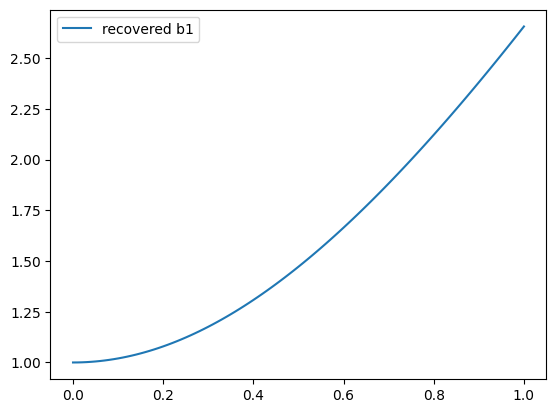

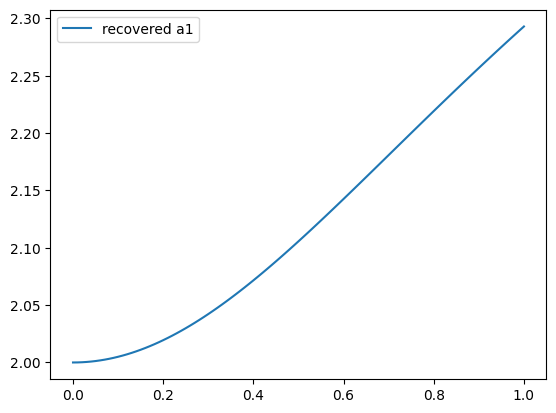

In [160]:
degree = 20
import sympy as sp
from sympy import lambdify
b_nfit_HA = []
print(bstraightofs.shape, a_vals.shape)
for j in range(bstraightofs.shape[1]):
    coeffs = np.polyfit(ss, bstraightofs[:,j], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    b_nfit_HA.append(str(poly_expr))

a_nfit_HA=[]

for j in range(astraightofs.shape[1]):
    coeffs = np.polyfit(ss, astraightofs[:,j], deg=degree)
    poly_expr = sum(sp.Float(c) * s**(degree - i) for i, c in enumerate(coeffs))
    poly_expr = sp.expand(poly_expr)
    a_nfit_HA.append(str(poly_expr))


s = sp.symbols('s')
b1ofslambdified = lambdify(s, b_nfit_HA[0], modules='numpy')
plt.plot(ss, b1ofslambdified(ss), label='recovered b1')
plt.legend()
plt.show()

a1ofslambdified = lambdify(s, a_nfit_HA[0], modules='numpy')
plt.plot(ss, a1ofslambdified(ss), label='recovered a1')
plt.legend()
plt.show()


(100, 100, 101)


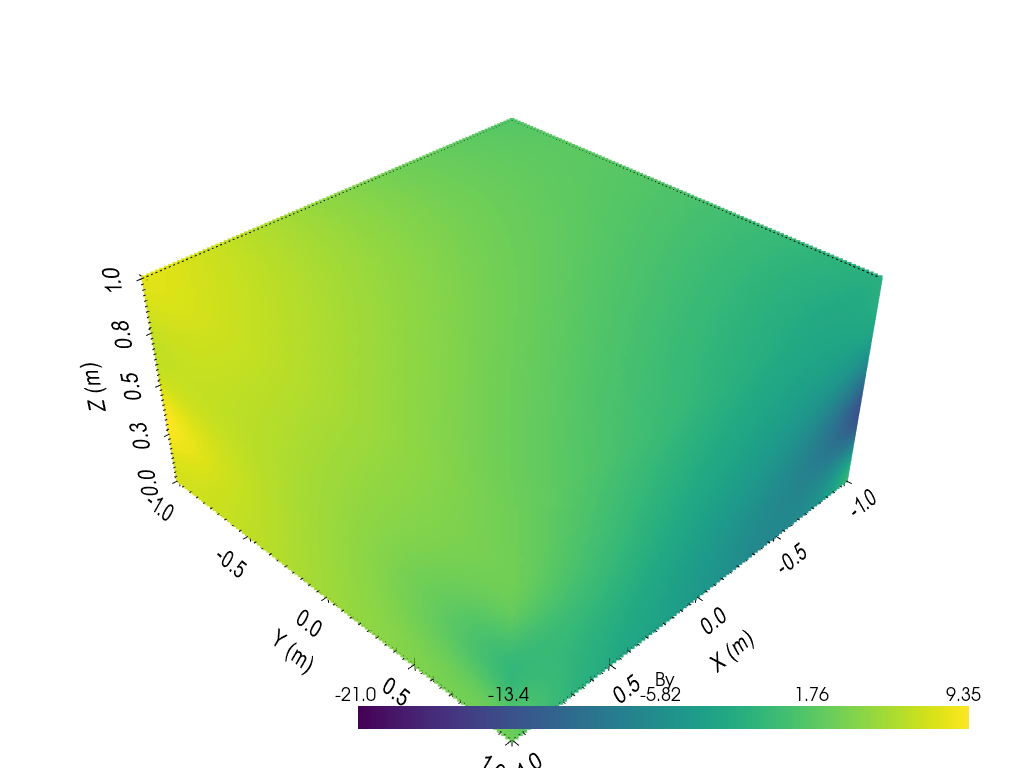

In [161]:
reconstruction_from_HA=bpmeth.FieldExpansion(a=a_nfit_HA, b=b_nfit_HA) 
#make a fieldmap of this reconstruction
Bx_rec_HA, By_rec_HA, Bs_rec_HA = reconstruction_from_HA.get_Bfield(lambdify=False)
Bxstraight_HA_array = np.asarray(sp.lambdify((x, y, s), Bx_rec_HA, 'numpy')(Xstraight, Ystraight, Sstraight))
Bystraight_HA_array = np.asarray(sp.lambdify((x, y, s), By_rec_HA, 'numpy')(Xstraight, Ystraight, Sstraight))
Bsstraight_HA_array = np.asarray(sp.lambdify((x, y, s), Bs_rec_HA, 'numpy')(Xstraight, Ystraight, Sstraight))
shape = Xstraight.shape  # reshape to (Nx, Ny, Ns)
Bxstraight_HA_array = np.broadcast_to(Bxstraight_HA_array, shape).copy()
Bystraight_HA_array = np.broadcast_to(Bystraight_HA_array, shape).copy()
Bsstraight_HA_array = np.broadcast_to(Bsstraight_HA_array, shape).copy()
#make a fieldmap object from the field arrays
print(Bxstraight_HA_array.shape)
datastraightHA = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_HA_array.flatten(), Bystraight_HA_array.flatten(), Bsstraight_HA_array.flatten()))

fm_rec_HA = bpmeth.fieldmaps.Fieldmap(datastraightHA)
fm_rec_HA.plot()

Now take the difference between the two reconstructions

/home/fmarcoli/bpmeth/src/bpmeth/fieldmaps.py:181: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


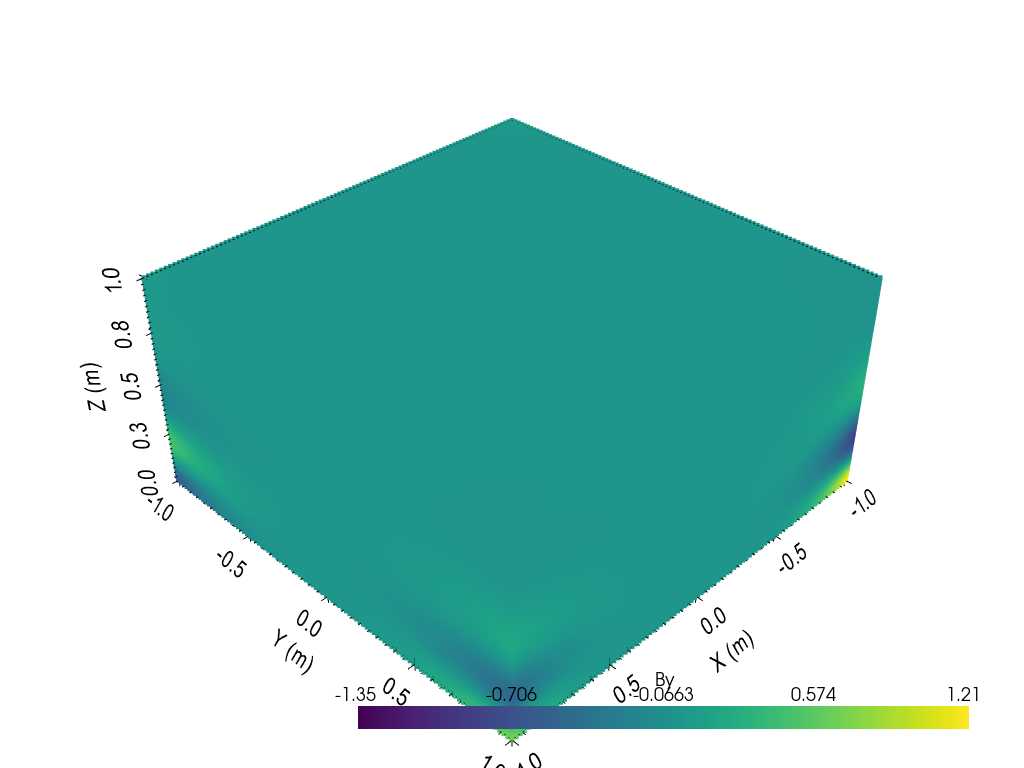

In [162]:
deltaBx=Bxstraight_phi_array-Bxstraight_HA_array
deltaBy=Bystraight_phi_array-Bystraight_HA_array
deltaBs=Bsstraight_phi_array-Bsstraight_HA_array

datadelta = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), deltaBx.flatten(), deltaBy.flatten(), deltaBs.flatten()))

fm_delta = bpmeth.fieldmaps.Fieldmap(datadelta)
fm_delta.plot()